# Notebook 02 — Khám phá Dữ liệu (Exploratory Data Analysis)

**Đề tài 7: Dự báo Năng suất Cây trồng**  
**Nhóm 13 | Dataset: Kaggle Crop Yield (28,242 dòng) | 2025–2026**

---
Notebook này thực hiện EDA toàn diện trên dataset đã ghép, bao gồm:
- Thống kê mô tả
- Phân tích phân phối và ngoại lệ
- Tương quan giữa các biến
- Phân tích theo quốc gia, loại cây và năm


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

PROC = Path("../data/processed")
OUT  = Path("../outputs/figures"); OUT.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROC / "crop_yield_main.csv")
print(f"Dataset: {df.shape[0]:,} dòng × {df.shape[1]} cột")
df.head()

Dataset: 28,242 dòng × 7 cột


,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


## 1. Thống kê mô tả

In [2]:
print("=== Thống kê tổng quan ===")
desc = df.describe().round(2)
print(desc)
print(f"\nSố quốc gia : {df.Area.nunique()}")
print(f"Số loại cây : {df.Item.nunique()}  → {df.Item.unique().tolist()}")
print(f"Phạm vi năm : {df.Year.min()} – {df.Year.max()}")
print(f"Missing values: {df.isnull().sum().to_dict()}")

=== Thống kê tổng quan ===
           Year  hg/ha_yield  average_rain_fall_mm_per_year  \
count  28242.00     28242.00                       28242.00   
mean    2001.54     77053.33                        1149.06   
std        7.05     84956.61                         709.81   
min     1990.00        50.00                          51.00   
25%     1995.00     19919.25                         593.00   
50%     2001.00     38295.00                        1083.00   
75%     2008.00    104676.75                        1668.00   
max     2013.00    501412.00                        3240.00   

       pesticides_tonnes  avg_temp  
count           28242.00  28242.00  
mean            37076.91     20.54  
std             59958.78      6.31  
min                 0.04      1.30  
25%              1702.00     16.70  
50%             17529.44     21.51  
75%             48687.88     26.00  
max            367778.00     30.65  

Số quốc gia : 101
Số loại cây : 10  → ['Maize', 'Potatoes', 'Rice, padd

## 2. Phân phối biến mục tiêu (Yield)

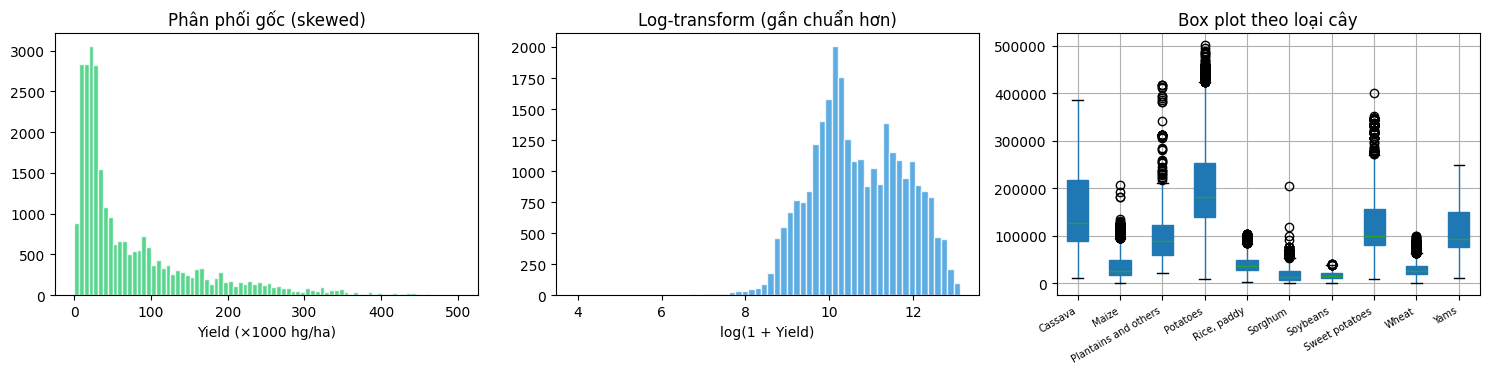

[SAVED] 02_yield_distribution.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Phân phối Năng suất (hg/ha)", fontsize=13, fontweight="bold")

axes[0].hist(df["hg/ha_yield"]/1000, bins=80, color="#2ecc71", alpha=0.8, edgecolor="white")
axes[0].set_title("Phân phối gốc (skewed)"); axes[0].set_xlabel("Yield (×1000 hg/ha)")

axes[1].hist(np.log1p(df["hg/ha_yield"]), bins=60, color="#3498db", alpha=0.8, edgecolor="white")
axes[1].set_title("Log-transform (gần chuẩn hơn)"); axes[1].set_xlabel("log(1 + Yield)")

# Box plot by crop
df.boxplot(column="hg/ha_yield", by="Item", ax=axes[2], patch_artist=True)
axes[2].set_title("Box plot theo loại cây"); axes[2].set_xlabel(""); plt.sca(axes[2]); plt.xticks(rotation=30, ha="right", fontsize=7)
plt.suptitle("")

plt.tight_layout()
plt.savefig(OUT / "02_yield_distribution.png", dpi=100, bbox_inches="tight"); plt.show()
print("[SAVED] 02_yield_distribution.png")

## 3. Phân tích theo Loại Cây trồng

=== Năng suất theo loại cây (hg/ha) ===
                      Yield_TB  Yield_Median  Độ_lệch  Số_mẫu
Item                                                         
Potatoes              199802.0      182271.0  93382.0    4276
Cassava               150479.0      128200.0  89739.0    2045
Sweet potatoes        119058.0       99940.0  69848.0    2890
Yams                  114140.0       92593.0  54212.0     847
Plantains and others  106041.0       89860.0  72128.0     556
Rice, paddy            40730.0       35878.0  19170.0    3388
Maize                  36310.0       25401.0  27456.0    4121
Wheat                  30116.0       25497.0  18388.0    3857
Sorghum                18636.0       12885.0  15118.0    3039
Soybeans               16731.0       15533.0   7603.0    3223


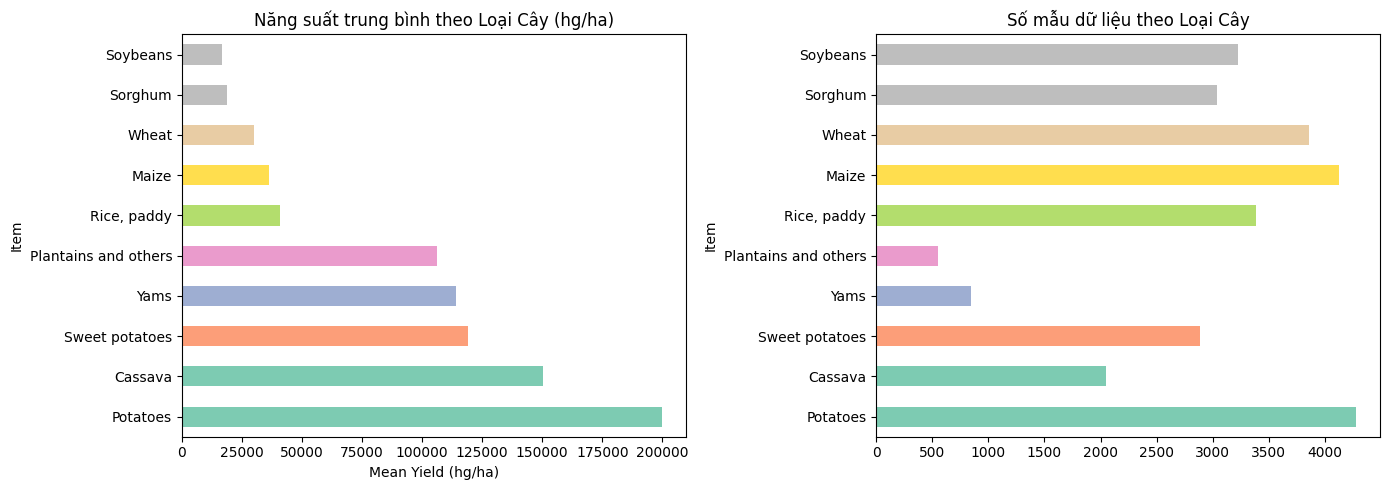

In [4]:
crop_stats = df.groupby("Item")["hg/ha_yield"].agg(["mean","median","std","count"]).round(0).sort_values("mean", ascending=False)
crop_stats.columns = ["Yield_TB","Yield_Median","Độ_lệch","Số_mẫu"]
print("=== Năng suất theo loại cây (hg/ha) ===")
print(crop_stats.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.Set2(np.linspace(0, 1, len(crop_stats)))
crop_stats["Yield_TB"].plot(kind="barh", ax=axes[0], color=colors, alpha=0.85)
axes[0].set_title("Năng suất trung bình theo Loại Cây (hg/ha)"); axes[0].set_xlabel("Mean Yield (hg/ha)")

crop_stats["Số_mẫu"].plot(kind="barh", ax=axes[1], color=colors, alpha=0.85)
axes[1].set_title("Số mẫu dữ liệu theo Loại Cây")

plt.tight_layout()
plt.savefig(OUT / "02_by_crop.png", dpi=100, bbox_inches="tight"); plt.show()

## 4. Xu hướng theo Năm (Time-Series)

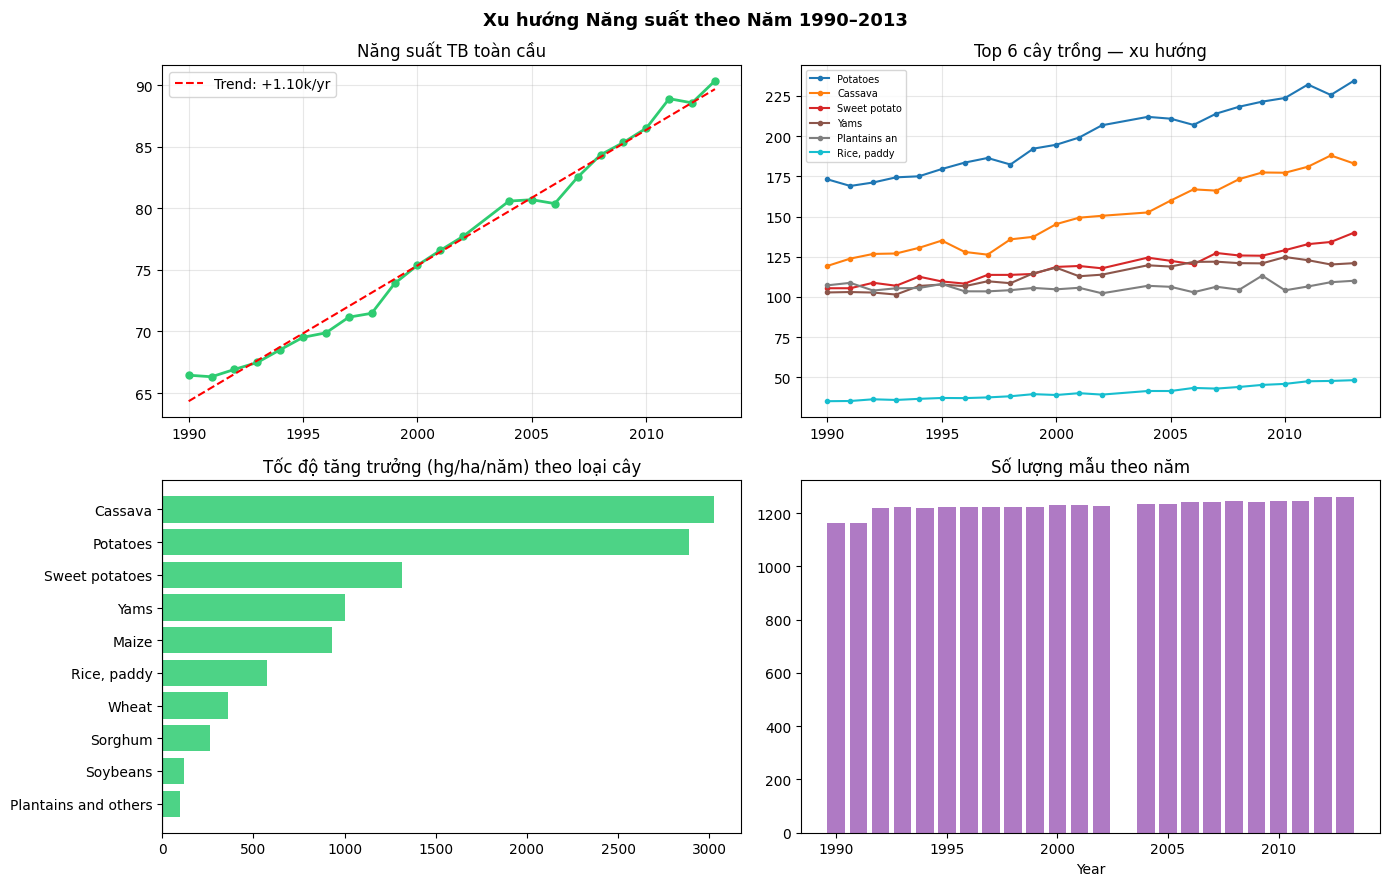

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Xu hướng Năng suất theo Năm 1990–2013", fontsize=13, fontweight="bold")

# Tổng thể
yr = df.groupby("Year")["hg/ha_yield"].mean()
coef = np.polyfit(yr.index, yr.values, 1)
axes[0,0].plot(yr.index, yr.values/1000, "o-", color="#2ecc71", linewidth=2, markersize=5)
axes[0,0].plot(yr.index, np.polyval(coef, yr.index)/1000, "r--", linewidth=1.5, label=f"Trend: {coef[0]/1000:+.2f}k/yr")
axes[0,0].set_title("Năng suất TB toàn cầu"); axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

# Theo từng loại cây
crops_to_plot = df.groupby("Item")["hg/ha_yield"].mean().sort_values(ascending=False).head(6).index
colors6 = plt.cm.tab10(np.linspace(0, 0.9, 6))
for i, crop in enumerate(crops_to_plot):
    sub = df[df.Item==crop].groupby("Year")["hg/ha_yield"].mean()
    axes[0,1].plot(sub.index, sub.values/1000, "o-", label=crop[:12], linewidth=1.5, markersize=3, color=colors6[i])
axes[0,1].set_title("Top 6 cây trồng — xu hướng"); axes[0,1].legend(fontsize=7); axes[0,1].grid(True, alpha=0.3)

# Tăng trưởng tuyệt đối
trends = {}
for crop in df.Item.unique():
    sub = df[df.Item==crop].groupby("Year")["hg/ha_yield"].mean()
    if len(sub) >= 5:
        c = np.polyfit(sub.index, sub.values, 1)
        trends[crop] = c[0]
trend_s = pd.Series(trends).sort_values()
clr = ["#e74c3c" if v < 0 else "#2ecc71" for v in trend_s.values]
axes[1,0].barh(trend_s.index, trend_s.values, color=clr, alpha=0.85)
axes[1,0].axvline(0, color="black", linewidth=0.8)
axes[1,0].set_title("Tốc độ tăng trưởng (hg/ha/năm) theo loại cây")

# Số mẫu theo năm
yr_cnt = df.groupby("Year").size()
axes[1,1].bar(yr_cnt.index, yr_cnt.values, color="#9b59b6", alpha=0.8)
axes[1,1].set_title("Số lượng mẫu theo năm"); axes[1,1].set_xlabel("Year")

plt.tight_layout()
plt.savefig(OUT / "02_time_series.png", dpi=100, bbox_inches="tight"); plt.show()

## 5. Phân tích Top Quốc gia

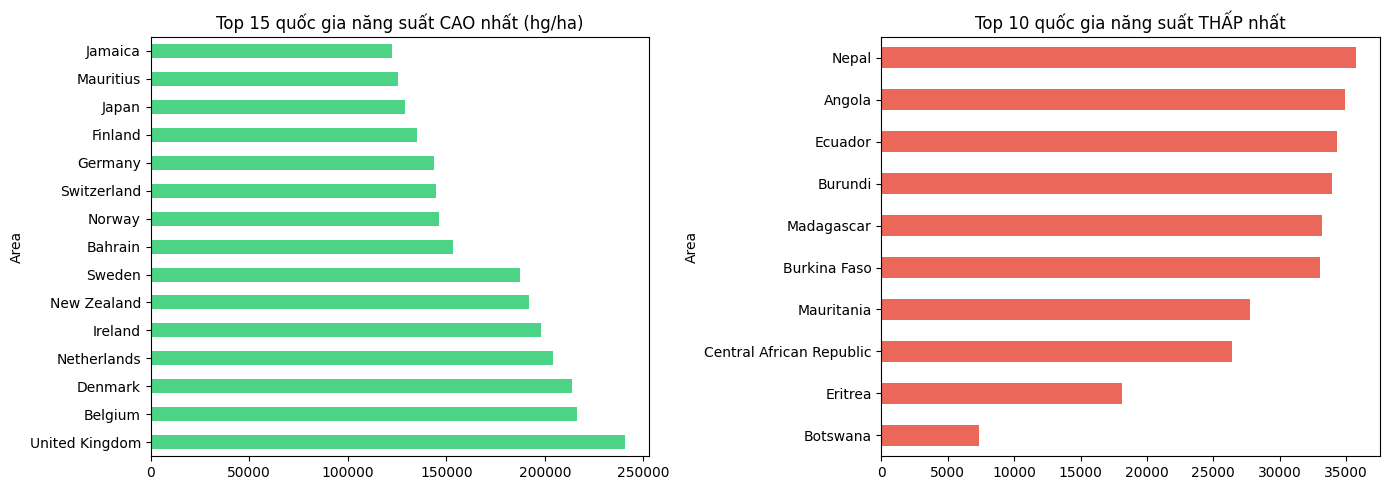

Top 15 quốc gia:
Area
United Kingdom    240956.0
Belgium           216468.0
Denmark           214033.0
Netherlands       204151.0
Ireland           197914.0
New Zealand       191932.0
Sweden            187406.0
Bahrain           153238.0
Norway            146115.0
Switzerland       144960.0
Germany           143631.0
Finland           135015.0
Japan             128852.0
Mauritius         125586.0
Jamaica           122348.0


In [6]:
top_countries = df.groupby("Area")["hg/ha_yield"].mean().sort_values(ascending=False).head(15)
bot_countries = df.groupby("Area")["hg/ha_yield"].mean().sort_values().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_countries.plot(kind="barh", ax=axes[0], color="#2ecc71", alpha=0.85)
axes[0].set_title("Top 15 quốc gia năng suất CAO nhất (hg/ha)")
bot_countries.plot(kind="barh", ax=axes[1], color="#e74c3c", alpha=0.85)
axes[1].set_title("Top 10 quốc gia năng suất THẤP nhất")
plt.tight_layout()
plt.savefig(OUT / "02_by_country.png", dpi=100, bbox_inches="tight"); plt.show()

print("Top 15 quốc gia:")
print(top_countries.round(0).to_string())

## 6. Ma trận Tương quan & Scatter plots

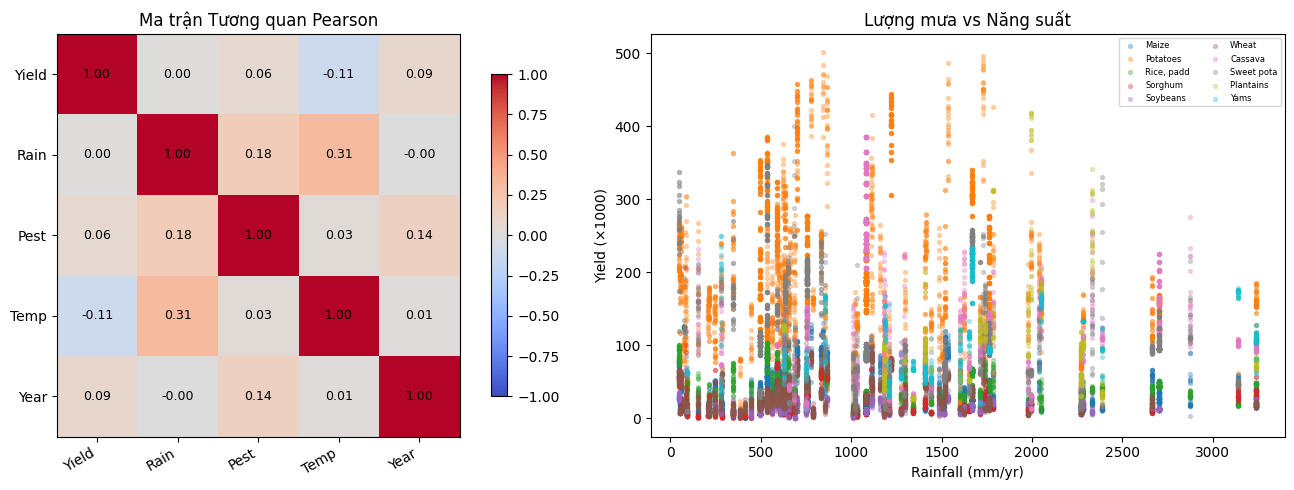

Tương quan với Yield:
average_rain_fall_mm_per_year    0.0010
pesticides_tonnes                0.0641
avg_temp                        -0.1148
Year                             0.0916
Name: hg/ha_yield, dtype: float64


In [7]:
numeric = df[["hg/ha_yield","average_rain_fall_mm_per_year","pesticides_tonnes","avg_temp","Year"]]
corr = numeric.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
im = axes[0].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
lbls = ["Yield","Rain","Pest","Temp","Year"]
axes[0].set_xticks(range(5)); axes[0].set_yticks(range(5))
axes[0].set_xticklabels(lbls, rotation=30, ha="right"); axes[0].set_yticklabels(lbls)
for i in range(5):
    for j in range(5): axes[0].text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=axes[0], shrink=0.8); axes[0].set_title("Ma trận Tương quan Pearson")

# Scatter: Rain vs Yield colored by crop
crops_list = df.Item.unique()
colors_c = plt.cm.tab10(np.linspace(0, 0.9, len(crops_list)))
for i, crop in enumerate(crops_list):
    sub = df[df.Item==crop]
    axes[1].scatter(sub["average_rain_fall_mm_per_year"], sub["hg/ha_yield"]/1000, c=[colors_c[i]], s=8, alpha=0.3, label=crop[:10])
axes[1].set_title("Lượng mưa vs Năng suất"); axes[1].set_xlabel("Rainfall (mm/yr)"); axes[1].set_ylabel("Yield (×1000)")
axes[1].legend(fontsize=6, ncol=2)

plt.tight_layout()
plt.savefig(OUT / "02_correlation.png", dpi=100, bbox_inches="tight"); plt.show()
print("Tương quan với Yield:")
print(corr["hg/ha_yield"].drop("hg/ha_yield").round(4))